In [1]:
#pip install duckdb

In [2]:
#import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Instalar la librería gdown si es necesario
#!pip install --upgrade gdown

# import gdown
# import os

# # 2. Configuración del ID del archivo y la URL de descarga
# FILE_ID = '1kDasOXgXimvPn2Shu3wgZymbqj4_8pDc'  
# url = f'https://drive.google.com/uc?id={FILE_ID}'
# output_file = '2019-Oct.csv'

# # 3. Descargar el archivo solo si no existe localmente (para evitar descargas repetidas)
# if not os.path.exists(output_file):
#     print("Iniciando la descarga del dataset de 5GB desde Google Drive...")
#     # gdown se encarga de gestionar la advertencia de tamaño de Google
#     gdown.download(url, output_file, quiet=False)
#     print("¡Descarga completada!")
# else:
#     print("El archivo ya existe en el entorno local.")

Dado el problema de los eventos raros (pocas compras, muchas vistas), lo ideal es no es hacer una muestra 100% aleatoria de todo, sino un muestreo estratificado: traer *TODAS* las compras (para no perder ni un solo dato de ventas) y una muestra del 2% de las vistas (porque todas las vistas se comportan de manera similar).

In [4]:
# con = duckdb.connect()

# # Query para traer:
# # 1. El 100% de los eventos 'purchase' y 'cart'
# # 2. Solo un 2% de los eventos 'view' para no saturar la memoria
# query = """
#     SELECT * FROM read_csv_auto('2019-Oct.csv') 
#     USING SAMPLE 500000;
# """

# # Ejecutamos y guardamos en un DataFrame de Pandas
# df_muestra = con.execute(query).df()

# print(f"Tamaño de la muestra: {len(df_muestra)} filas")
# print(df_muestra['event_type'].value_counts())

Este fue el resultado de hacer un muestrero aleatorio de 500000 registros de la base de datos 2019-Oct.csv

- Tamaño de la muestra: 500000 filas
event_type
- view        480542
- cart         10851
- purchase      8607
- Name: count, dtype: int64

In [5]:
#df_muestra.to_csv('muestra_eventos.csv', index=False)

In [6]:
df_muestra = pd.read_csv("./raw/muestra_eventos_def.csv")
print(df_muestra.shape)
df_muestra.head()

(500000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-16 14:47:46,view,25600036,2053013559675191951,NaN,mart,270.25,520700334,cf4b59d7-51ce-4235-bff1-2e023521d038
1,2019-10-31 11:06:12,view,1005115,2053013555631882655,electronics.smartphone,apple,952.37,529546123,1c0ab992-d849-4cfb-9c52-44ee750ebe6e
2,2019-10-24 10:33:09,view,1004227,2053013555631882655,electronics.smartphone,apple,1002.57,546385140,e5953cd4-124a-4341-b3e4-95c7933f42cc
3,2019-10-11 10:14:00,view,23300386,2053013561956893455,NaN,arua,30.86,551689123,a21706f9-7631-4ff0-a7d1-eee00d45acf6
4,2019-10-20 09:07:45,view,1005014,2053013555631882655,electronics.smartphone,samsung,544.38,558151232,47c24ba5-1cb4-4d4e-bb80-42ab2006ae6b


## Inspección básica del dataset

In [7]:
print(df_muestra.info())

print("\nColumns:")
print(df_muestra.columns)

print("\nData Types:")
print(df_muestra.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  341012 non-null  object 
 5   brand          427912 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 34.3+ MB
None

Columns:
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

Data Types:
event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             objec

               Missing Values  Missing Percentage
category_code          158988             31.7976
brand                   72088             14.4176
event_time                  0              0.0000
product_id                  0              0.0000
event_type                  0              0.0000
category_id                 0              0.0000
price                       0              0.0000
user_id                     0              0.0000
user_session                0              0.0000


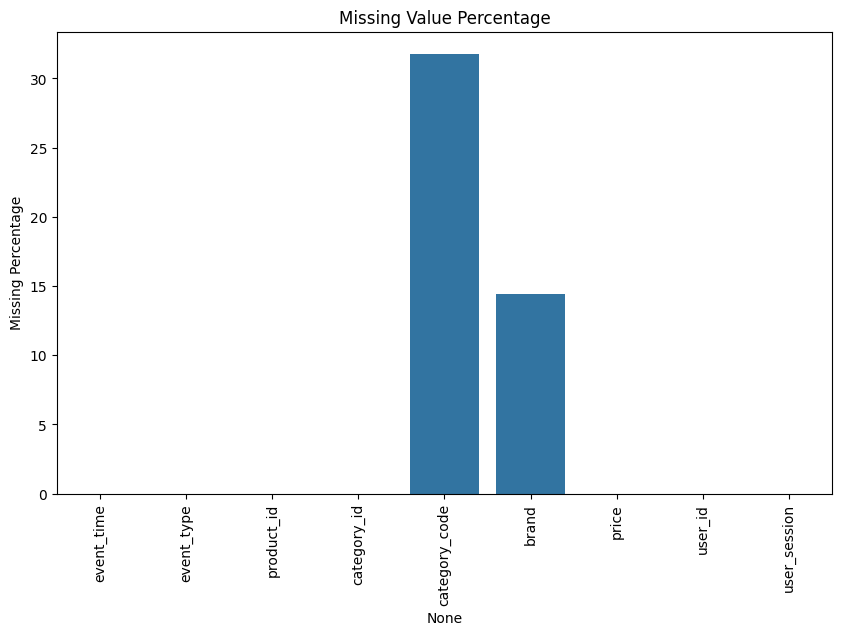

In [8]:
missing_values = df_muestra.isnull().sum()

missing_percentage = (df_muestra.isnull().sum() / len(df_muestra)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

print(missing_df.sort_values(by='Missing Percentage', ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_df.index,
    y=missing_df['Missing Percentage']
)
plt.xticks(rotation=90)
plt.title("Missing Value Percentage")
plt.show()

## 1. Estructura básica

In [9]:
print('─── Dimensiones ───')
print(f'{df_muestra.shape[0]:,} filas  ×  {df_muestra.shape[1]} columnas\n')

print('─── Tipos de datos ───')
print(df_muestra.dtypes)

print('\n─── Muestra aleatoria ───')
display(df_muestra.sample(5, random_state=42))

─── Dimensiones ───
500,000 filas  ×  9 columnas

─── Tipos de datos ───
event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object

─── Muestra aleatoria ───


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
104241,2019-10-04 11:32:25,cart,5100816,2053013553375346967,NaN,xiaomi,28.56,518709055,e3e3145b-b5b7-4de7-b6b3-34d5b6a2ee9f
199676,2019-10-20 13:16:13,view,11400620,2053013558458843721,NaN,inkax,5.15,538043243,2ddada0b-5c76-4c46-955e-fb7cfd575545
140199,2019-10-25 07:42:37,view,13200013,2053013557192163841,furniture.bedroom.bed,sv,141.32,521349611,5398eba0-09fb-46ae-9d3f-9904f0a7534b
132814,2019-10-03 17:45:43,view,26201887,2053013563693335403,NaN,NaN,126.39,539232781,f1d2a521-5e23-45b9-a36b-653219878d11
408697,2019-10-25 08:38:17,view,1004104,2053013555631882655,electronics.smartphone,bq,174.53,563526004,6e37cccd-ae64-48aa-a2c1-a09945b73ca7


## 2. Nulos y duplicados

In [10]:
# ── Nulos ──────────────────────────────────────────────────────────
nulos = df_muestra.isnull().sum().rename('nulos')
pct   = (nulos / len(df_muestra) * 100).rename('pct_%').round(2)
resumen_nulos = pd.concat([nulos, pct], axis=1)
print('─── Valores nulos ───')
display(resumen_nulos[resumen_nulos['nulos'] > 0])

# ── Duplicados ─────────────────────────────────────────────────────
dupes = df_muestra.duplicated().sum()
print(f'\nFilas duplicadas exactas: {dupes:,}  ({dupes/len(df_muestra)*100:.2f}%)')

─── Valores nulos ───


,nulos,pct_%
category_code,158988,31.80
brand,72088,14.42



Filas duplicadas exactas: 11  (0.00%)


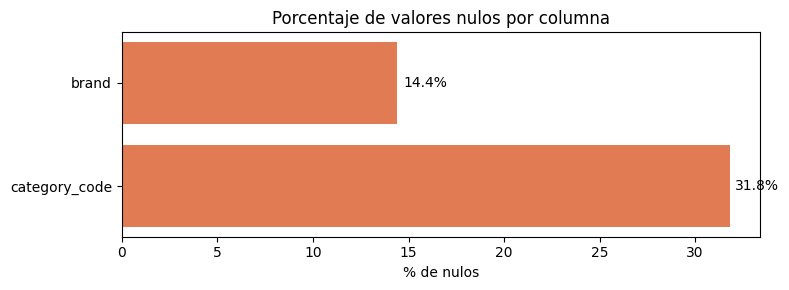

In [11]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(8, 3))
cols_con_nulos = resumen_nulos[resumen_nulos['nulos'] > 0]
ax.barh(cols_con_nulos.index, cols_con_nulos['pct_%'], color='#e07b54')
ax.set_xlabel('% de nulos')
ax.set_title('Porcentaje de valores nulos por columna')
for i, v in enumerate(cols_con_nulos['pct_%']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

## 3. Conversión de tipos

In [12]:
df_muestra['event_time'] = pd.to_datetime(df_muestra['event_time'])

# Columnas de texto → category (ahorra memoria)
for col in ['event_type', 'category_code', 'brand']:
    df_muestra[col] = df_muestra[col].astype('category')

print('Tipos actualizados:')
print(df_muestra.dtypes)
print(f'\nRango temporal: {df_muestra["event_time"].min()}  →  {df_muestra["event_time"].max()}')

Tipos actualizados:
event_time       datetime64[ns]
event_type             category
product_id                int64
category_id               int64
category_code          category
brand                  category
price                   float64
user_id                   int64
user_session             object
dtype: object

Rango temporal: 2019-10-01 00:01:14  →  2019-10-31 23:59:53


## 4. Estadísticas descriptivas

In [13]:
display(df_muestra.describe(include='all').T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
event_time,500000,NaN,NaN,NaN,2019-10-16 13:06:25.565040128,2019-10-01 00:01:14,2019-10-09 08:19:26.750000128,2019-10-16 12:17:13.500000,2019-10-23 17:55:24.249999872,2019-10-31 23:59:53,NaN
event_type,500000,3,view,480542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,500000.0,NaN,NaN,NaN,10563480.609758,1000978.0,1005158.0,5000475.0,16000723.25,60500010.0,11908708.643652
category_id,500000.0,NaN,NaN,NaN,2057436946699072000.0,2053013552226107648.0,2053013555464110592.0,2053013555631882752.0,2053013563391345408.0,2175419595093967616.0,18493208918131348.0
category_code,341012,125,electronics.smartphone,135466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,427912,2512,samsung,62070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,500000.0,NaN,NaN,NaN,289.405417,0.0,65.64,162.14,358.57,2574.07,356.659243
user_id,500000.0,NaN,NaN,NaN,533482860.34586,239876607.0,515881596.5,529529659.0,551531691.5,566276055.0,18533376.535673
user_session,500000,465223,cfb90a35-9575-495c-b6aa-48ddca2a7a9c,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Variable objetivo: `event_type`

,conteo,%
event_type,,
view,480542,96.11
cart,10851,2.17
purchase,8607,1.72


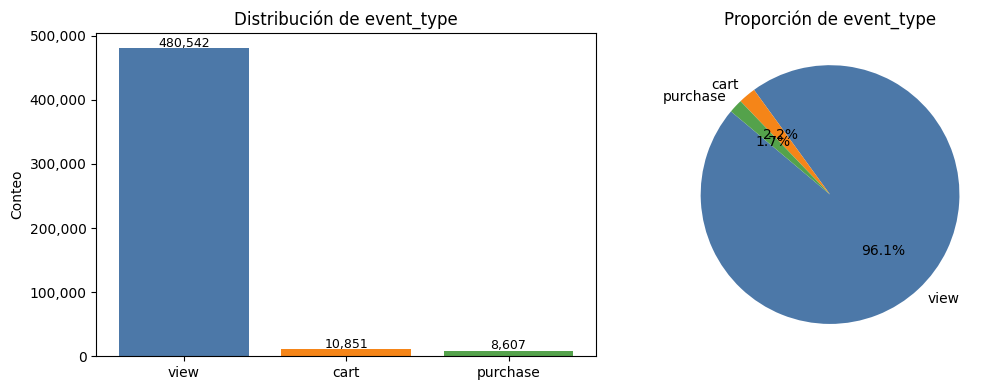


─── Funnel de conversión ───
view  → cart:     2.26%
cart  → purchase: 79.32%
view  → purchase: 1.79%


In [14]:
import matplotlib.ticker as mticker

vc = df_muestra['event_type'].value_counts()
pct_et = (vc / len(df_muestra) * 100).round(2)
display(pd.DataFrame({'conteo': vc, '%': pct_et}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras
axes[0].bar(vc.index, vc.values, color=['#4c78a8','#f58518','#54a24b'])
axes[0].set_title('Distribución de event_type')
axes[0].set_ylabel('Conteo')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

# Pie — escala log para ver minorías
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['#4c78a8','#f58518','#54a24b'], startangle=140)
axes[1].set_title('Proporción de event_type')

plt.tight_layout()
plt.show()

# Funnel de conversión
views     = vc.get('view', 0)
carts     = vc.get('cart', 0)
purchases = vc.get('purchase', 0)
print('\n─── Funnel de conversión ───')
print(f'view  → cart:     {carts/views*100:.2f}%')
print(f'cart  → purchase: {purchases/carts*100:.2f}%')
print(f'view  → purchase: {purchases/views*100:.2f}%')

## 6. Distribución de precios

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21860\1450457499.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='event_type', y='price', order=order,


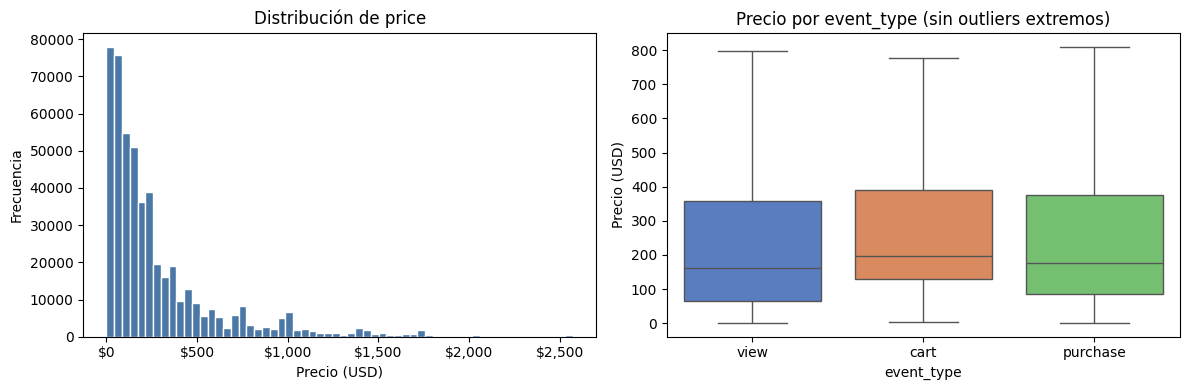

─── Precio medio por event_type ───


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21860\1450457499.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_muestra.groupby('event_type')['price'].agg(['mean','median','std']).round(2))


,mean,median,std
event_type,,,
cart,331.40,196.87,351.55
purchase,308.01,176.33,350.52
view,288.12,160.62,356.82


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma general
axes[0].hist(df_muestra['price'], bins=60, color='#4c78a8', edgecolor='white')
axes[0].set_title('Distribución de price')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Boxplot por event_type
order = ['view', 'cart', 'purchase']
df_box = df_muestra[df_muestra['price'] > 0]  # excluir ceros
sns.boxplot(data=df_box, x='event_type', y='price', order=order,
            palette='muted', ax=axes[1], showfliers=False)
axes[1].set_title('Precio por event_type (sin outliers extremos)')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()

# Precio medio por tipo de evento
print('─── Precio medio por event_type ───')
display(df_muestra.groupby('event_type')['price'].agg(['mean','median','std']).round(2))

## 7. Categorías y marcas

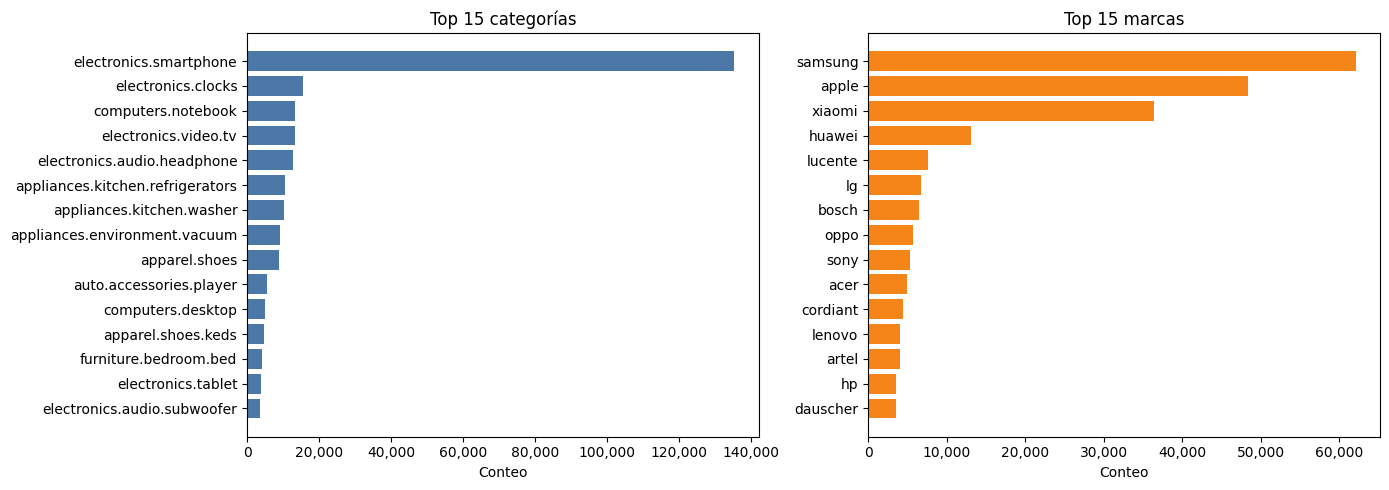

In [16]:
TOP_N = 15

top_cats   = df_muestra['category_code'].value_counts().head(TOP_N)
top_brands = df_muestra['brand'].value_counts().head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_cats.index[::-1], top_cats.values[::-1], color='#4c78a8')
axes[0].set_title(f'Top {TOP_N} categorías')
axes[0].set_xlabel('Conteo')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top_brands.index[::-1], top_brands.values[::-1], color='#f58518')
axes[1].set_title(f'Top {TOP_N} marcas')
axes[1].set_xlabel('Conteo')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21860\766336728.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('brand')['price']


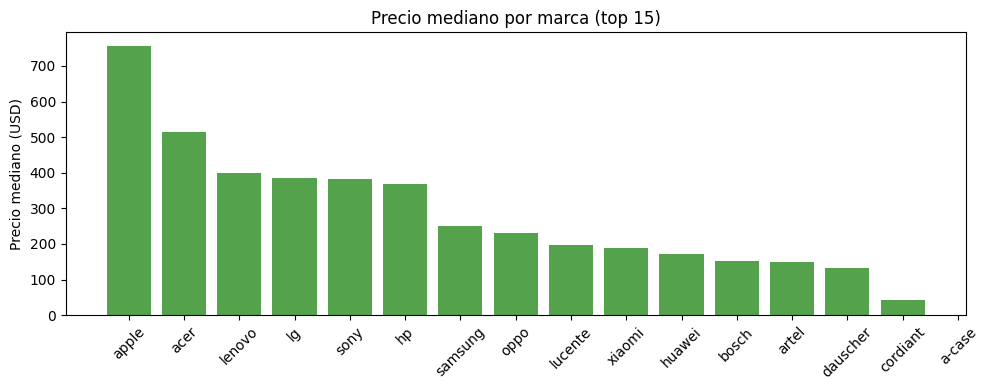

In [17]:
# Precio mediano por top marcas
top_brand_names = top_brands.index.tolist()
precio_marca = (
    df_muestra[df_muestra['brand'].isin(top_brand_names)]
    .groupby('brand')['price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(precio_marca.index, precio_marca.values, color='#54a24b')
ax.set_title('Precio mediano por marca (top 15)')
ax.set_ylabel('Precio mediano (USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Análisis temporal

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21860\3382683106.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily = df_muestra.groupby(['date', 'event_type']).size().unstack(fill_value=0)


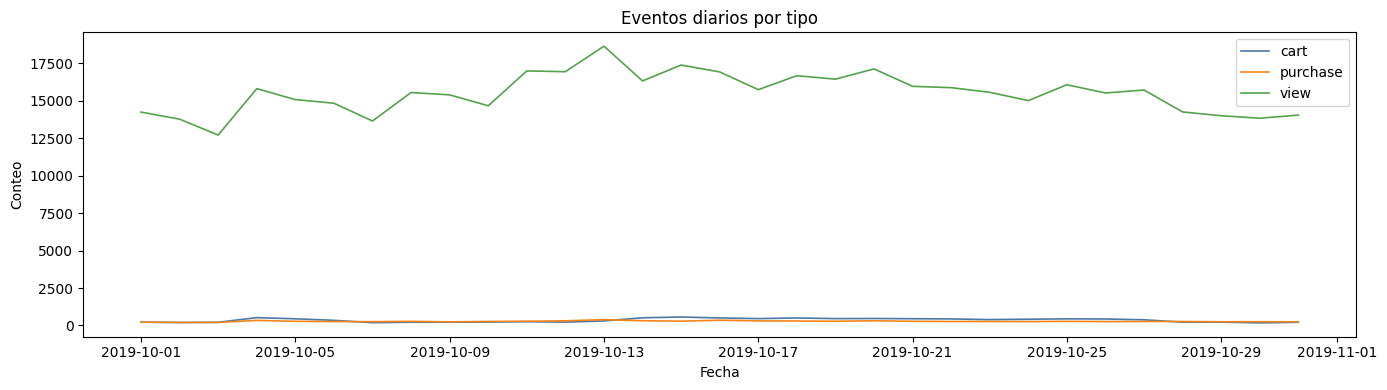

In [18]:
df_muestra['date']      = df_muestra['event_time'].dt.date
df_muestra['hour']      = df_muestra['event_time'].dt.hour
df_muestra['dayofweek'] = df_muestra['event_time'].dt.day_name()

# Eventos diarios
daily = df_muestra.groupby(['date', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
for col, color in zip(daily.columns, ['#4c78a8','#f58518','#54a24b']):
    ax.plot(daily.index, daily[col], label=col, color=color, linewidth=1.2)
ax.set_title('Eventos diarios por tipo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21860\2287344054.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_counts = df_muestra.groupby(['hour', 'event_type']).size().unstack(fill_value=0)


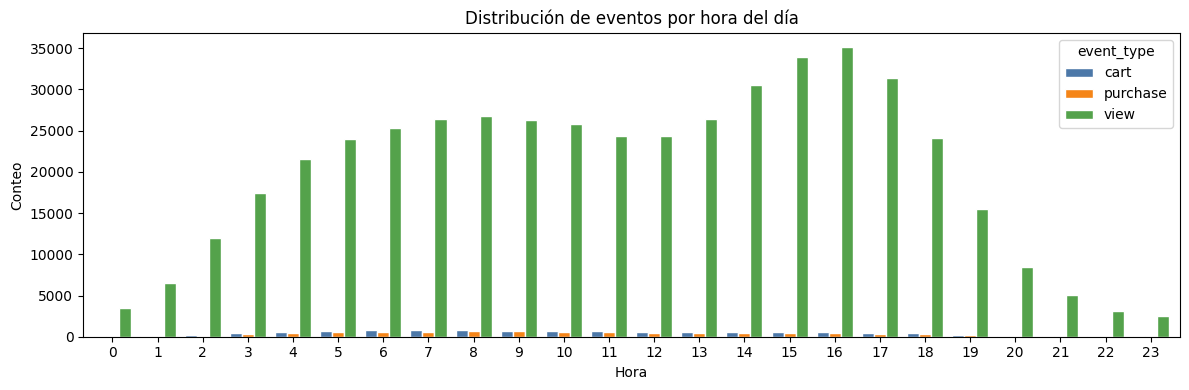

In [19]:
# Distribución por hora del día
hour_counts = df_muestra.groupby(['hour', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
hour_counts.plot(kind='bar', ax=ax, color=['#4c78a8','#f58518','#54a24b'],
                 edgecolor='white', width=0.8)
ax.set_title('Distribución de eventos por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

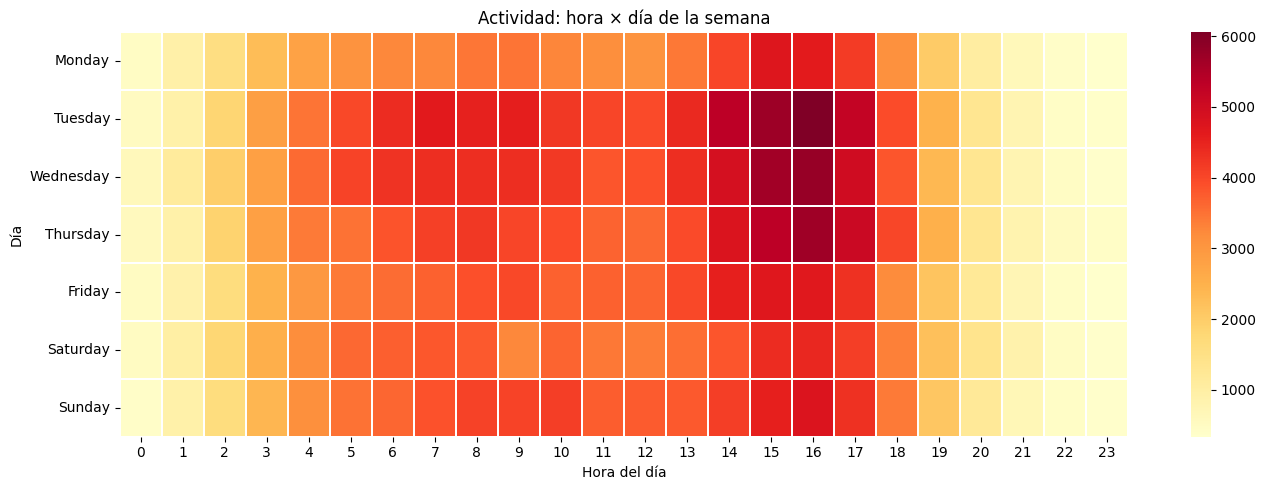

In [20]:
# Heatmap: hora × día de la semana
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = (
    df_muestra.groupby(['dayofweek', 'hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(order_days)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            linewidths=0.3, fmt=',d', annot=False)
ax.set_title('Actividad: hora × día de la semana')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día')
plt.tight_layout()
plt.show()

## 9. Comportamiento de usuarios

─── Eventos por usuario ───
count    364677.00
mean          1.37
std           0.97
min           1.00
25%           1.00
50%           1.00
75%           1.00
max         101.00
dtype: float64

Usuarios únicos: 364,677
Sesiones únicas: 465,223


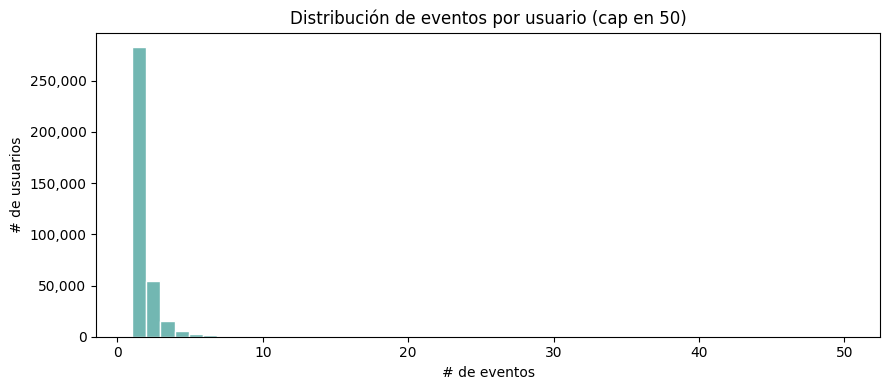

In [21]:
# Eventos por usuario
user_activity = df_muestra.groupby('user_id').size()

print('─── Eventos por usuario ───')
print(user_activity.describe().round(2))
print(f'\nUsuarios únicos: {df_muestra["user_id"].nunique():,}')
print(f'Sesiones únicas: {df_muestra["user_session"].nunique():,}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(user_activity.clip(upper=50), bins=50, color='#72b7b2', edgecolor='white')
ax.set_title('Distribución de eventos por usuario (cap en 50)')
ax.set_xlabel('# de eventos')
ax.set_ylabel('# de usuarios')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [22]:
# Top compradores (por valor total de compras)
top_buyers = (
    df_muestra[df_muestra['event_type'] == 'purchase']
    .groupby('user_id')['price']
    .agg(n_purchases='count', total_spent='sum')
    .sort_values('total_spent', ascending=False)
    .head(10)
)
print('─── Top 10 compradores por valor total ───')
display(top_buyers.style.format({'total_spent': '${:,.2f}'}))

─── Top 10 compradores por valor total ───


,n_purchases,total_spent
user_id,,
512498872,3,"$3,418.98"
551346693,2,"$3,277.50"
519250600,2,"$3,273.93"
515650586,3,"$3,209.05"
559715691,3,"$3,165.38"
521721550,3,"$3,131.10"
529340419,3,"$2,994.87"
519267944,2,"$2,970.17"
513348652,2,"$2,878.87"


## 10. Correlación (variables numéricas)

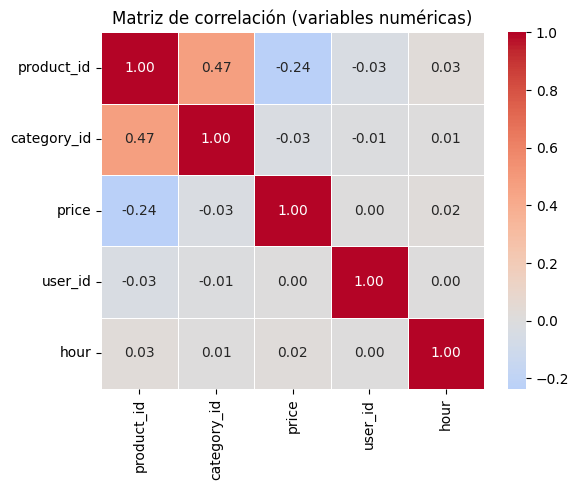

In [23]:
num_cols = df_muestra.select_dtypes(include='number').columns.tolist()
# product_id, category_id y user_id son IDs; solo precio es relevante numéricamente
# Aun así mostramos la matriz para completitud
corr = df_muestra[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

## 11. Resumen ejecutivo

In [24]:
views     = (df_muestra['event_type'] == 'view').sum()
carts     = (df_muestra['event_type'] == 'cart').sum()
purchases = (df_muestra['event_type'] == 'purchase').sum()
revenue   = df_muestra[df_muestra['event_type'] == 'purchase']['price'].sum()

print('═' * 52)
print('  RESUMEN EDA — muestra_eventos_def')
print('═' * 52)
print(f'  Filas totales          : {len(df_muestra):>12,}')
print(f'  Rango temporal         : {df_muestra["event_time"].min().date()} → {df_muestra["event_time"].max().date()}')
print(f'  Usuarios únicos        : {df_muestra["user_id"].nunique():>12,}')
print(f'  Sesiones únicas        : {df_muestra["user_session"].nunique():>12,}')
print(f'  Productos únicos       : {df_muestra["product_id"].nunique():>12,}')
print(f'  Categorías únicas      : {df_muestra["category_code"].nunique():>12,}')
print(f'  Marcas únicas          : {df_muestra["brand"].nunique():>12,}')
print('─' * 52)
print(f'  Views                  : {views:>12,} ({views/len(df_muestra)*100:.1f}%)')
print(f'  Carts                  : {carts:>12,} ({carts/len(df_muestra)*100:.1f}%)')
print(f'  Purchases              : {purchases:>12,} ({purchases/len(df_muestra)*100:.1f}%)')
print(f'  Conv. view→purchase    : {purchases/views*100:>11.2f}%')
print(f'  Revenue total          : ${revenue:>11,.2f}')
print(f'  Ticket promedio        : ${revenue/purchases:>11,.2f}')
print('─' * 52)
print(f'  Nulos en category_code : {df_muestra["category_code"].isnull().sum():>12,} ({df_muestra["category_code"].isnull().mean()*100:.1f}%)')
print(f'  Nulos en brand         : {df_muestra["brand"].isnull().sum():>12,} ({df_muestra["brand"].isnull().mean()*100:.1f}%)')
print('═' * 52)

════════════════════════════════════════════════════
  RESUMEN EDA — muestra_eventos_def
════════════════════════════════════════════════════
  Filas totales          :      500,000
  Rango temporal         : 2019-10-01 → 2019-10-31
  Usuarios únicos        :      364,677
  Sesiones únicas        :      465,223
  Productos únicos       :       63,842
  Categorías únicas      :          125
  Marcas únicas          :        2,512
────────────────────────────────────────────────────
  Views                  :      480,542 (96.1%)
  Carts                  :       10,851 (2.2%)
  Purchases              :        8,607 (1.7%)
  Conv. view→purchase    :        1.79%
  Revenue total          : $2,651,055.08
  Ticket promedio        : $     308.01
────────────────────────────────────────────────────
  Nulos en category_code :      158,988 (31.8%)
  Nulos en brand         :       72,088 (14.4%)
════════════════════════════════════════════════════
